In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
)
import ace_tools  # type: ignore


# ----------------- UTILIDADES -----------------
def cargar_equipo(csv_path: str, id_equipo: int, chunksize: int = 25_000) -> pd.DataFrame:
    partes = []
    for chunk in pd.read_csv(
        csv_path, parse_dates=["Fecha"], chunksize=chunksize, engine="python"
    ):
        partes.append(chunk[chunk["ID_Equipo"] == id_equipo])
    return pd.concat(partes, ignore_index=True)


def etiquetar_fallos(df: pd.DataFrame, horizonte: int = 15) -> pd.DataFrame:
    df = df.sort_values("Fecha").reset_index(drop=True).copy()
    correctivos = (df["Tipo_Mantenimiento"] == 1).values
    etiqueta = np.full(len(df), np.nan)
    for i in range(len(df) - horizonte):
        etiqueta[i] = 1 if correctivos[i : i + horizonte].any() else 0
    df[f"fallo_{horizonte}d"] = etiqueta
    return df.dropna(subset=[f"fallo_{horizonte}d"])


# ----------------- FUNCIÓN DE TUNING -----------------
def tune_random_forest(
    csv_path: str,
    id_equipo: int,
    horizonte: int = 15,
    weight_grid=(
        1,
        2,
        3,
        4,
        5,
        6,
        8,
        10,
    ),
    thresholds=np.arange(0.05, 1.0, 0.05),
):
    """Busca la mejor combinación class_weight & threshold."""
    # 1) Datos
    df_eq = cargar_equipo(csv_path, id_equipo)
    df_eq = etiquetar_fallos(df_eq, horizonte)

    vars_sensor = [
        "Temperatura_C",
        "Vibracion_mm_s",
        "Horas_Operativas",
        "horas_hasta_correctivo",
    ]
    X = df_eq[vars_sensor].values
    y = df_eq[f"fallo_{horizonte}d"].astype(int).values
    corte = int(len(df_eq) * 0.8)
    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]
    fechas_train = df_eq["Fecha"].iloc[:corte]
    fechas_test = df_eq["Fecha"].iloc[corte:]

    # 2) Grid Search
    rows = []
    best_row = None
    best_score = -np.inf

    for w0 in weight_grid:
        clf = RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight={0: w0, 1: 1},
        )
        clf.fit(X_train, y_train)
        proba_test = clf.predict_proba(X_test)[:, 1]

        for thr in thresholds:
            y_pred = (proba_test >= thr).astype(int)
            acc = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average="macro")
            f1_weighted = f1_score(y_test, y_pred, average="weighted")
            precision, recall, _, _ = precision_recall_fscore_support(
                y_test, y_pred, labels=[0, 1], zero_division=0
            )
            row = {
                "weight_0": w0,
                "threshold": thr,
                "accuracy": acc,
                "f1_macro": f1_macro,
                "f1_weighted": f1_weighted,
                "precision_0": precision[0],
                "recall_0": recall[0],
                "precision_1": precision[1],
                "recall_1": recall[1],
            }
            rows.append(row)

            # Selección sujeta a restricciones mínimas
            if (acc >= 0.80) and (f1_weighted >= 0.75):
                if f1_macro > best_score:
                    best_score = f1_macro
                    best_row = row.copy()

    df_metrics = pd.DataFrame(rows)
    ace_tools.display_dataframe_to_user(
        "Grid class_weight/threshold – Equipo 1", df_metrics.round(3)
    )

    if best_row is None:
        print(
            "⚠️  Ninguna combinación cumple simultáneamente "
            "accuracy ≥ 0.80 y F1_weighted ≥ 0.75."
        )
        return

    # 3) Entrenar de nuevo con el mejor weight
    w0_best = best_row["weight_0"]
    thr_best = best_row["threshold"]

    clf_best = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight={0: w0_best, 1: 1},
    )
    clf_best.fit(X_train, y_train)
    proba_test = clf_best.predict_proba(X_test)[:, 1]
    y_pred_best = (proba_test >= thr_best).astype(int)

    # 4) Gráfica
    plt.figure(figsize=(12, 4))
    plt.plot(fechas_train, y_train, alpha=0.4, label="Train (real)")
    plt.plot(
        fechas_test,
        y_test,
        linestyle="--",
        marker="o",
        markersize=3,
        label="Test (real)",
    )
    plt.plot(
        fechas_test,
        y_pred_best,
        linestyle=":",
        marker="x",
        markersize=4,
        label=f"Predicción (thr={thr_best:.2f}, w0={w0_best})",
    )
    plt.yticks([0, 1], ["Sin fallo", "Fallo"])
    plt.title(
        f"Equipo {id_equipo} – Mejor modelo\n"
        f"accuracy={best_row['accuracy']:.3f} "
        f"| F1_macro={best_row['f1_macro']:.3f}"
    )
    plt.xlabel("Fecha")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    print("🟢 Mejor combinación encontrada:")
    for k, v in best_row.items():
        print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")


# ----------------- EJECUCIÓN PARA EQUIPO 1 -----------------
tune_random_forest(
    "../data/Datos_limpios.csv",
    id_equipo=1,
    horizonte=15,
)




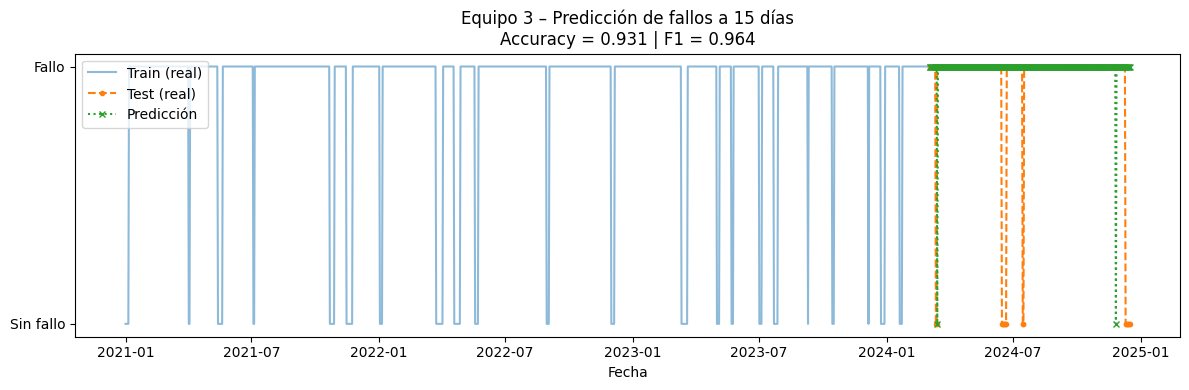

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        18
           1      0.938     0.993     0.964       272

    accuracy                          0.931       290
   macro avg      0.469     0.496     0.482       290
weighted avg      0.879     0.931     0.904       290



In [6]:
# ----------------- EJECUCIÓN PARA EQUIPO 1 -----------------
tune_random_forest(
    "/mnt/data/Datos_limpios.csv",
    id_equipo=1,
    horizonte=15,
)